# AdaSwarm Quickstart 🐝

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaSwarm/AdaSwarm/blob/main/examples/quickstart.ipynb)

**AdaSwarm augments a normal gradient optimiser (like Adam) with Particle Swarm Optimisation.**

The key idea in one line:

> AdaSwarm is a **drop-in loss function**. Keep your usual optimiser and training loop — just swap the criterion.

```
outputs = model(inputs)
loss = criterion(outputs, targets)   # <-- swap torch.nn.BCELoss() for adaswarm.nn.BCELoss()
loss.backward()
optimizer.step()                     # still plain Adam
```

This notebook trains the same tiny network on the classic **Iris** dataset twice — once with a standard loss and once with AdaSwarm — and plots the two accuracy curves side by side.

## 1. Install (Colab / fresh environment)

If you are running locally with the repo already installed (`uv sync`), you can skip this cell.

In [1]:
# Uncomment on Colab or a clean environment:
# %pip install "adaswarm[examples] @ git+https://github.com/AdaSwarm/AdaSwarm.git"

## 2. Imports

In [2]:
import matplotlib.pyplot as plt
import torch

import adaswarm.nn
from adaswarm.data import DataLoaderFetcher

print("AdaSwarm version:", adaswarm.__version__)
print("PyTorch version:", torch.__version__)

AdaSwarm version: 0.1.0
PyTorch version: 2.12.1


## 3. A single training function

The **only** line that differs between the two experiments is the `criterion`.
Everything else — model, optimiser, loop — is identical and completely standard.

In [3]:
def run_experiment(use_adaswarm: bool, epochs: int = 40, seed: int = 0):
    torch.manual_seed(seed)

    fetcher = DataLoaderFetcher(name="Iris")   # Iris is the default; no env vars needed
    train_loader = fetcher.train_loader()
    test_loader = fetcher.test_loader()
    model = fetcher.model()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)   # plain Adam either way

    # ---- the one and only difference ----
    criterion = adaswarm.nn.BCELoss() if use_adaswarm else torch.nn.BCELoss()

    test_accuracies = []
    for _ in range(epochs):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.float(), targets.float()
            optimizer.zero_grad()
            loss = criterion(model(inputs).float(), targets)
            loss.backward()
            optimizer.step()

        # evaluate at the end of each epoch
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                preds = model(inputs.float()).argmax(dim=1)
                correct += (preds == targets.argmax(dim=1)).sum().item()
                total += targets.size(0)
        test_accuracies.append(correct / total)

    return test_accuracies

## 4. Run both experiments

In [4]:
standard_curve = run_experiment(use_adaswarm=False)
adaswarm_curve = run_experiment(use_adaswarm=True)

print(f"Final accuracy — standard BCELoss: {standard_curve[-1]:.2%}")
print(f"Final accuracy — AdaSwarm BCELoss: {adaswarm_curve[-1]:.2%}")

Final accuracy — standard BCELoss: 93.33%
Final accuracy — AdaSwarm BCELoss: 90.00%


## 5. Plot the convergence

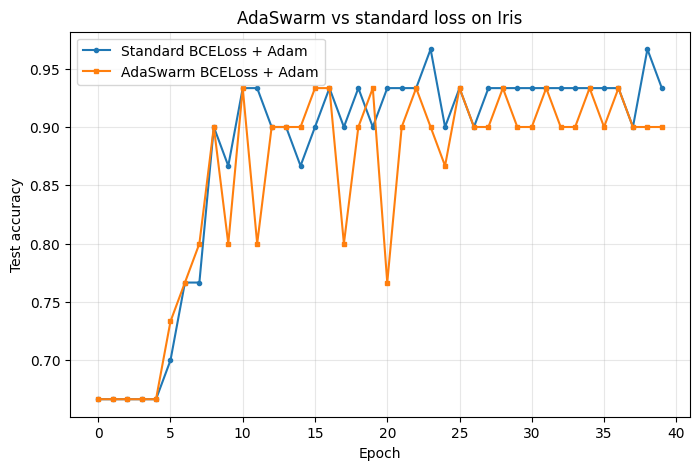

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(standard_curve, label="Standard BCELoss + Adam", marker="o", markersize=3)
plt.plot(adaswarm_curve, label="AdaSwarm BCELoss + Adam", marker="s", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("AdaSwarm vs standard loss on Iris")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Use it in your own project

That's it. To use AdaSwarm in your own training code:

```python
import torch
import adaswarm.nn

criterion = adaswarm.nn.BCELoss()                      # or adaswarm.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

for inputs, targets in loader:
    optimizer.zero_grad()
    loss = criterion(model(inputs), targets)
    loss.backward()
    optimizer.step()
```

- Use `adaswarm.nn.BCELoss()` for binary / one-hot targets (tabular problems).
- Use `adaswarm.nn.CrossEntropyLoss()` for multi-class classification (e.g. images).

See the [README](https://github.com/AdaSwarm/AdaSwarm) for more detail and the paper.